# Creando Bases de datos en AWS

En este notebook vamos a crear una base de datos MariaDB (SQL) y MongoDB (NoSQL) en AWS.

Vamos a poder comparar el proceso y los pasos a seguir para su creación y conexión.

## 1- Creación de una instancia de RDS con MariaDB

En AWS, RDS (Relational Data Service), es el lugar donde podemos crear instancias de bases de datos relacionales.

#### ¿Qué es MariaDB?

MariaDB es una base de datos relacional de código abierto que se deriva de MySQL y mantiene una alta compatibilidad con él, pero con características adicionales que la hacen una opción atractiva para muchos proyectos.
Sus principales características son:

- Alto rendimiento y escalabilidad -> En consultas simples y medianas, con optimizaciones de almacenamiento y capacidades de replicación avanzadas.
- Compatibilidad con MySQL -> Debido a que MariaDB es un fork de MySQL, las aplicaciones que utilizan MySQL generalmente pueden cambiar a MariaDB sin necesidad de realizar cambios significativos en el código.
- Almacenamiento en columna -> Más eficiente en consultas analíticas y de lectura intensiva. Esto es particularmente útil en aplicaciones que requieren consultas complejas sobre grandes volúmenes de datos.
- Facilidad de uso y administración



### Ahora entonces, vamos a crear nuestra instancia de MariaDB


- Busquemos en la barra de búsqueda RDS
- En la pantalla principal de RDS, haremos clic en **Crear base de datos**

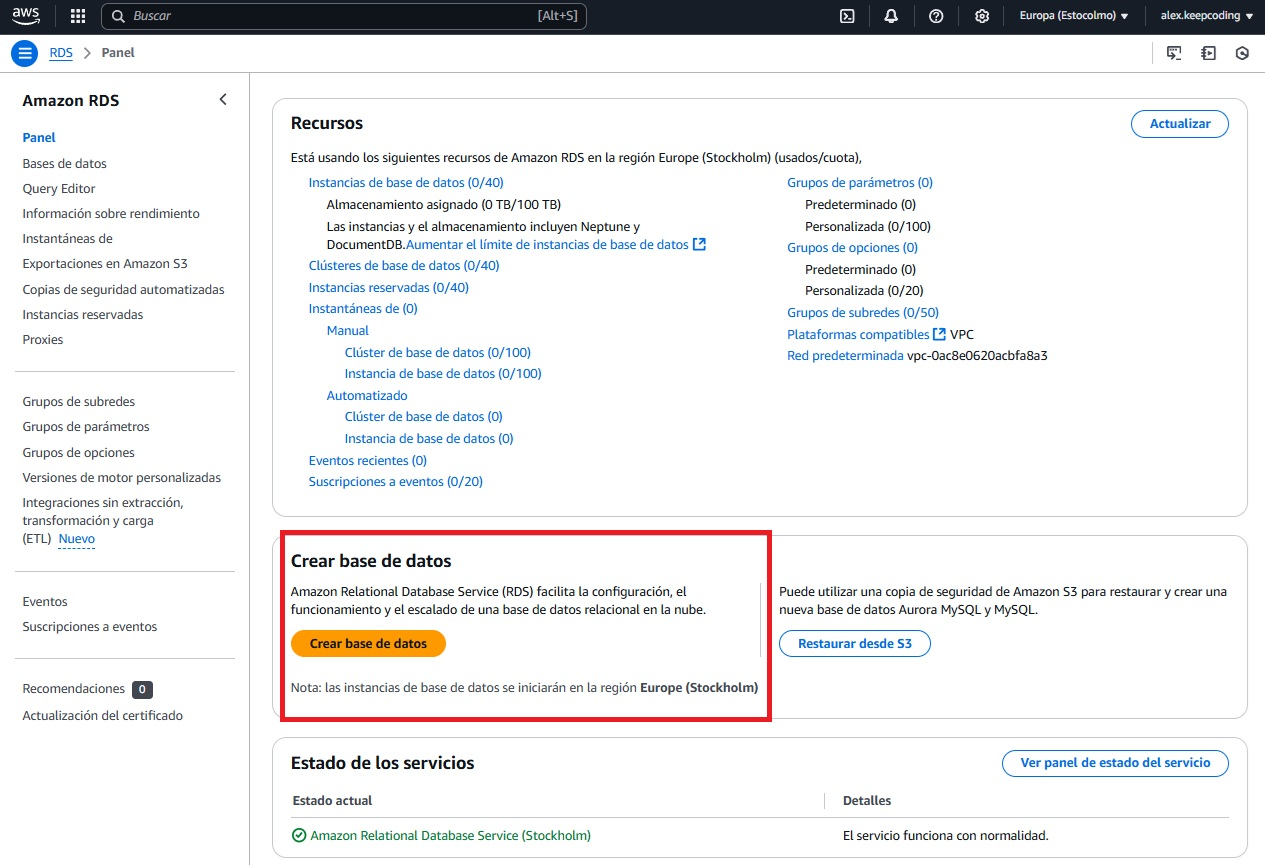

Fijaos cómo tenemos más opciones de bases de datos relacionales. Nosotros vamos a seleccionar MariaDB:

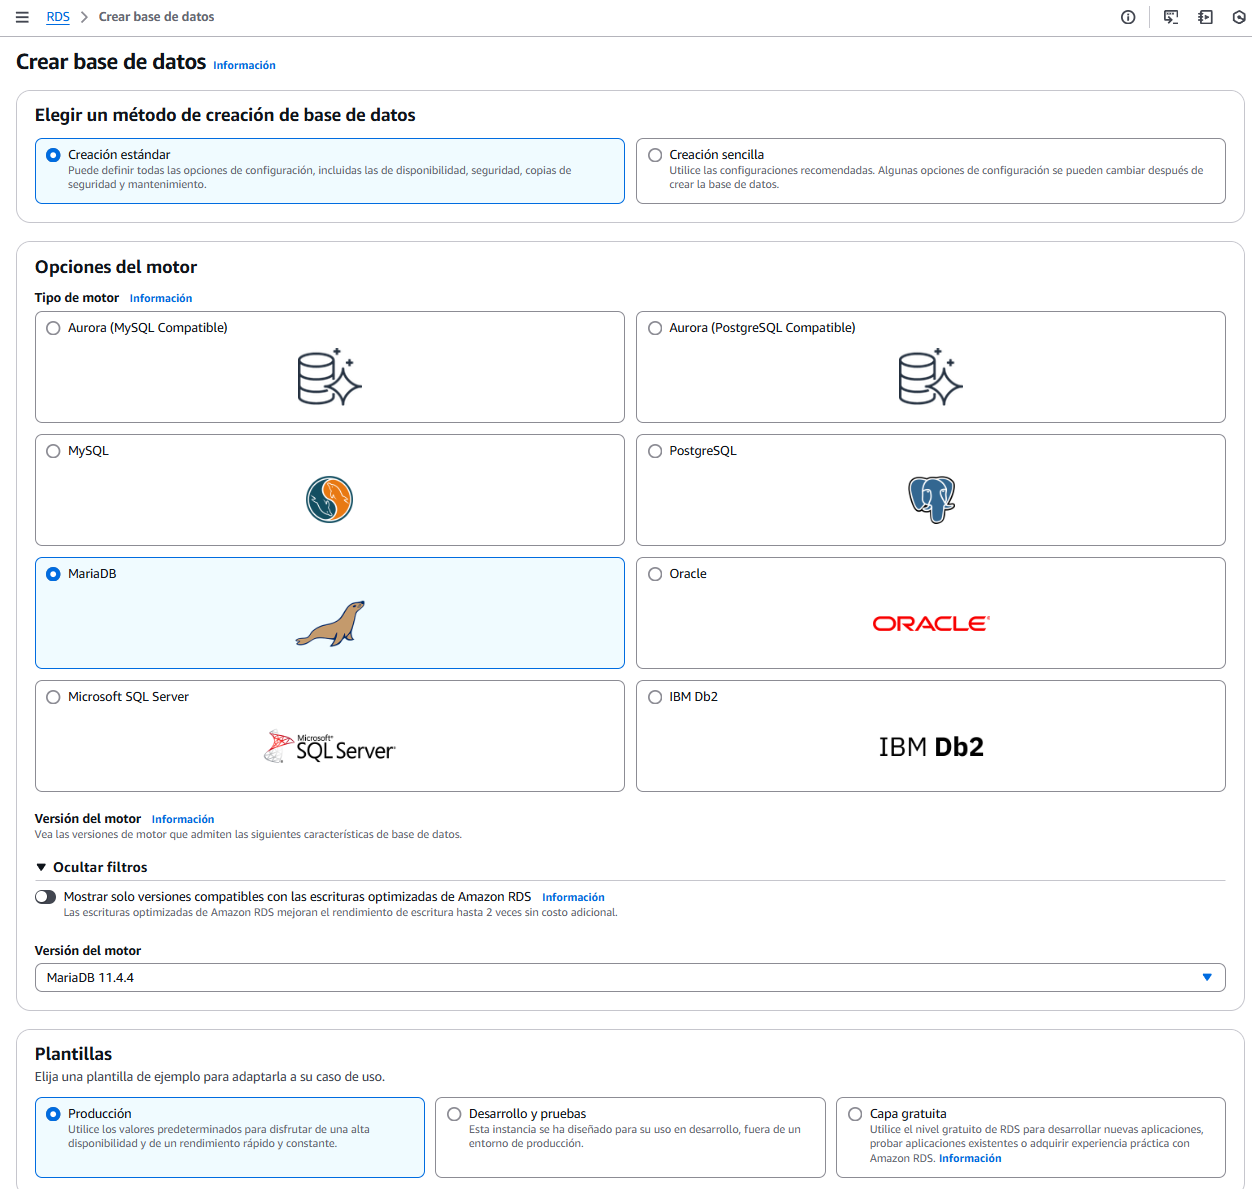

Para la configuración, utilizaremos lo siguiente:

Plantilla: *Capa gratuita*
Identificador de instancias de bases de datos: *maria-1*
Nombre de usuario maestro: *admin*
Administración de credenciales: *Autoadministrado*
Contraseña maestra: *password*
Configuración de la instancia: *db.t3.micro*

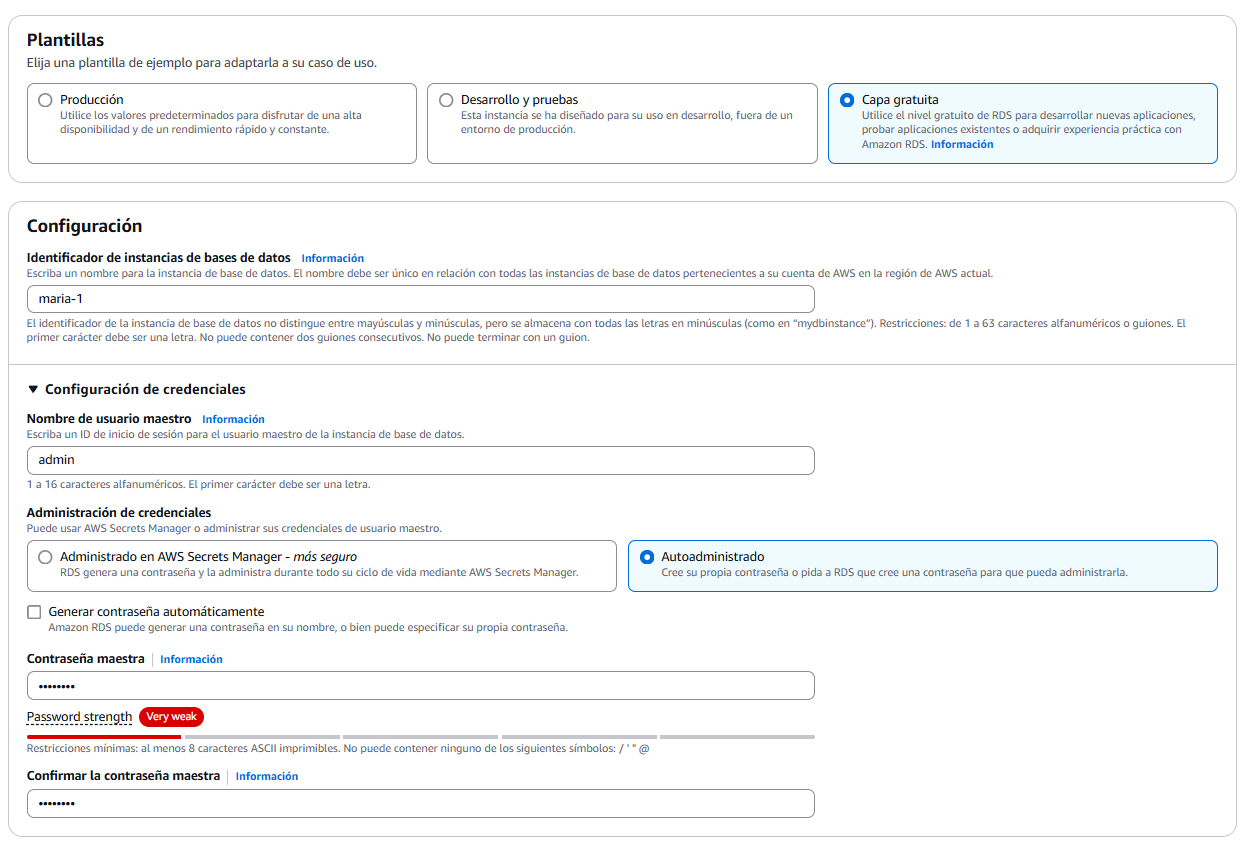

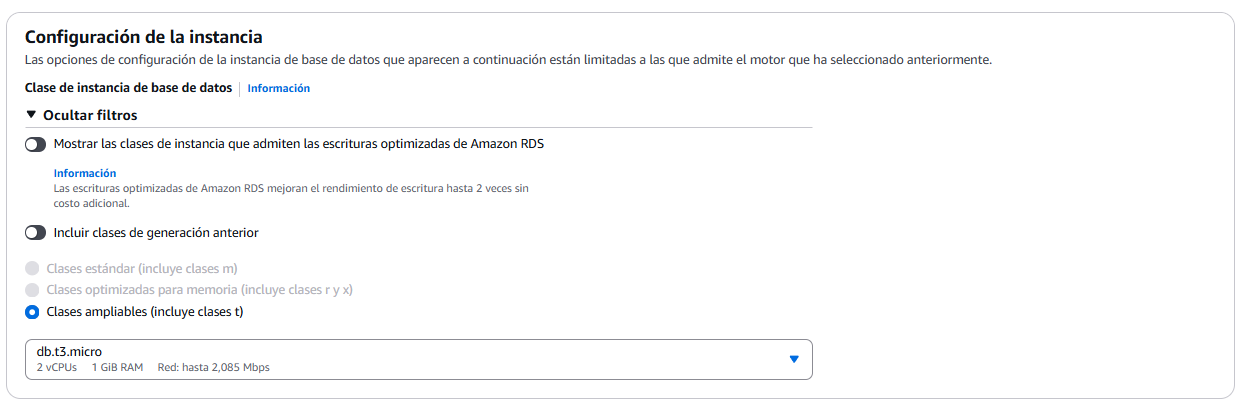

Antes de crearla, veamos las opciones de **Conectividad** (es importante entenderlas):


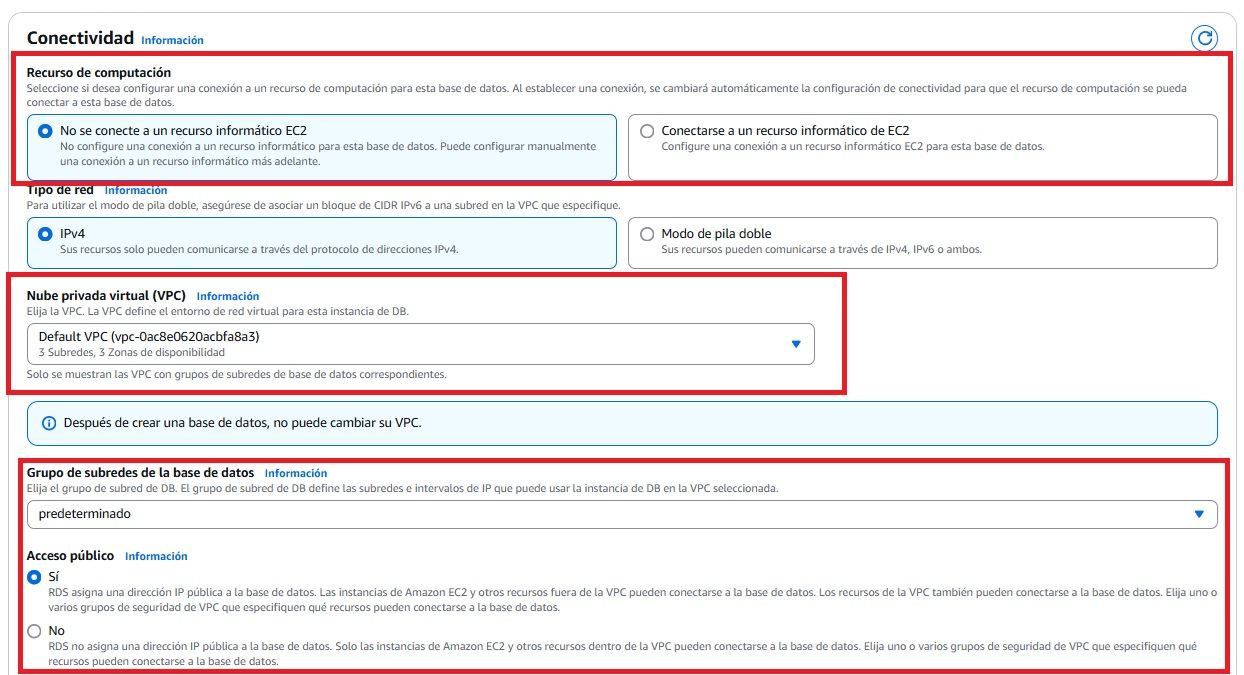


En esta ocasión no nos vamos a conectar a ninguna máquina virtual aparte.
Además, debemos elegir qué VPN definirá el entorno de red virtual para esta instancia (ahora nos quedaremos con la Default, que se crea al crear nuestra cuenta de AWS).
Le daremos acceso público para poder acceder a ella desde fuera de AWS.

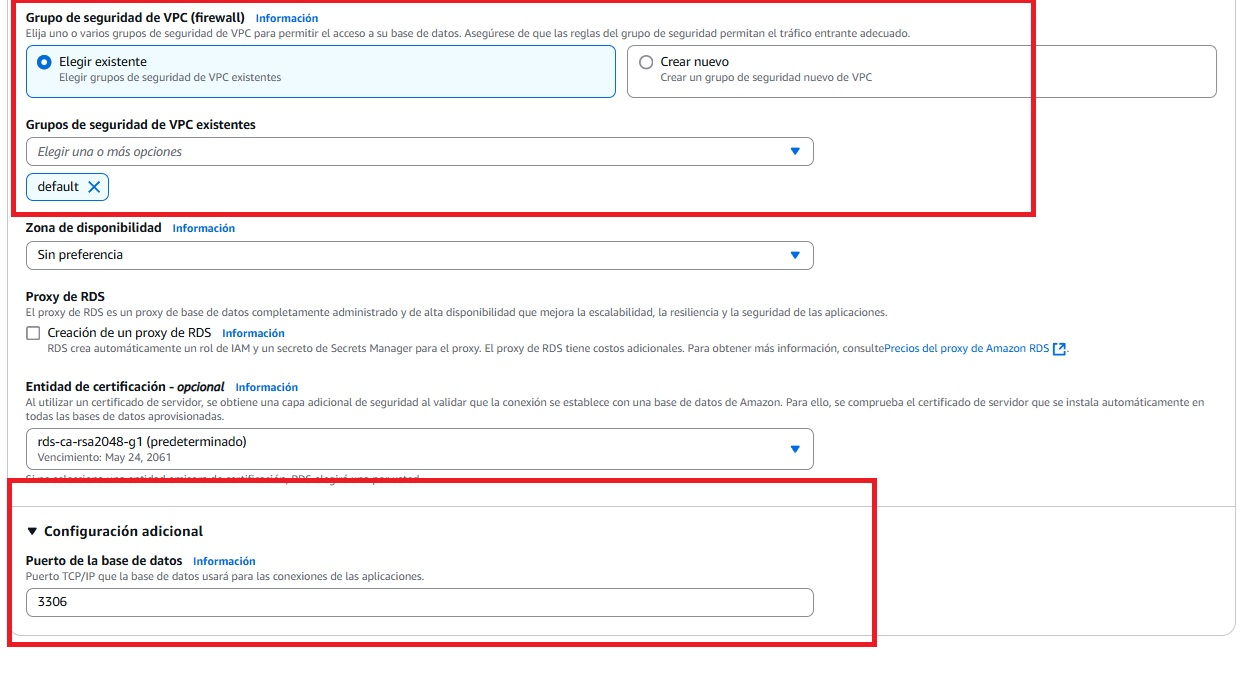

Respecto del Grupo de Seguridad (firewall), nos quedaremos con el default.
Elegiremos además el puerto 3306, que es **el puerto por el que escucha MariaDB** (Esto es bastante diferente a como configuramos la regla de firewall en GCP).

Y con esto, bajamos y le damos a **Crear base de datos**
(Tardará un poquito en crearse)

Una vez creada la instancia, debemos hacer una **configuración en el grupo de seguridad**.

Para eso, dentro de nuestra instancia vamos a hacer click en el grupo de seguridad seleccionado para la instancia:

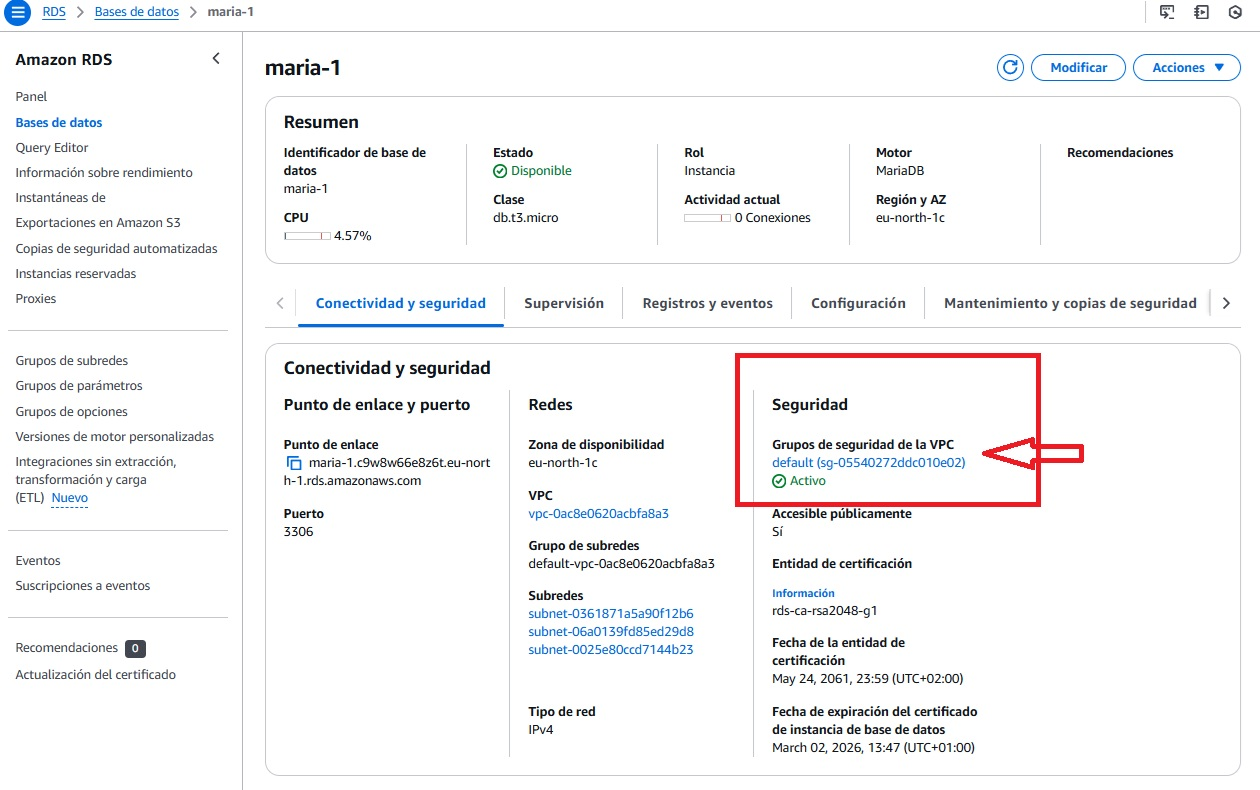

Esto nos llevará a los **Grupos de Seguridad**,y haremos click en el Id del grupo que tenemos creado:

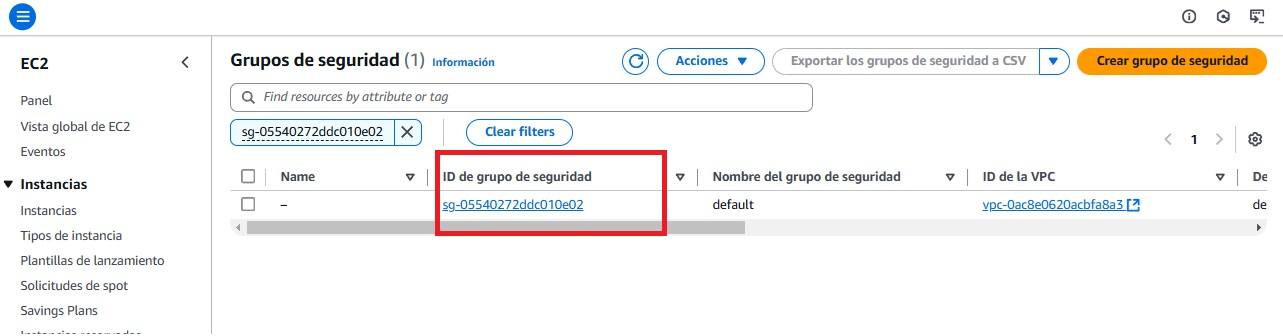

Aquí lo que queremos es **Editar las reglas de entrada**:

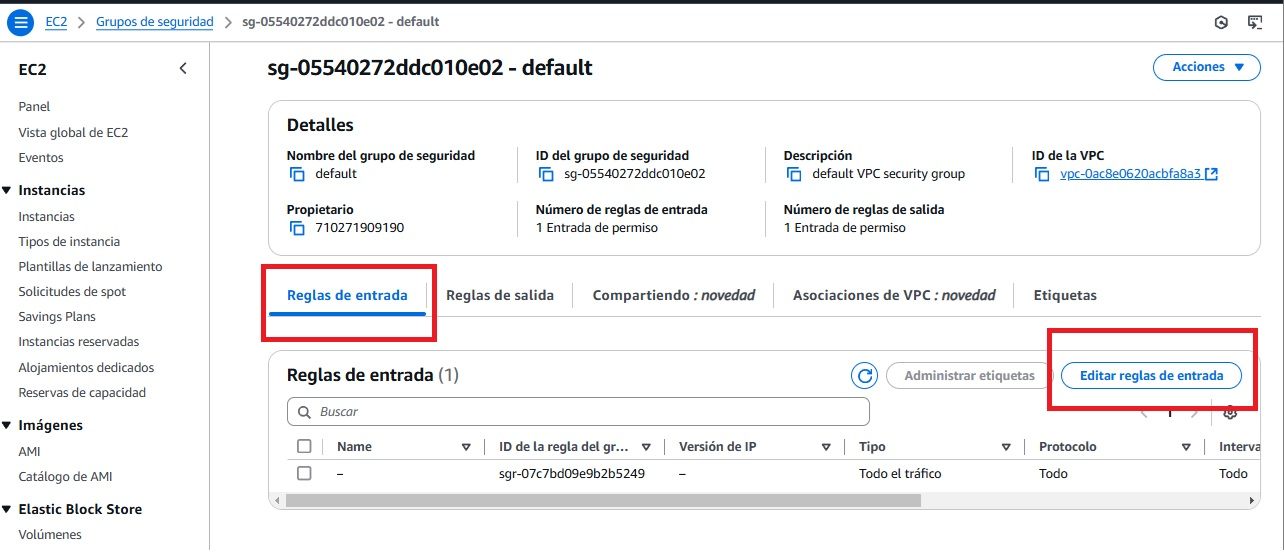

Ahora vamos a configurar el acceso desde nuestro notebook

In [ ]:
!curl ifconfig.me

34.48.35.79

Agregamos la IP de nuestro notebook:

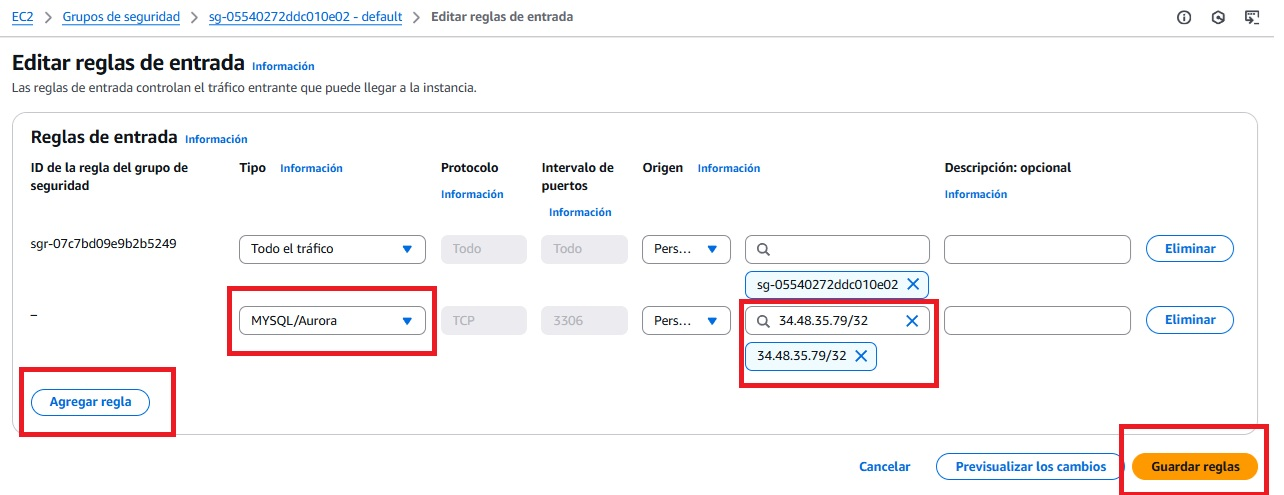

**Hay que seleccionar el tipo MYSQL/Aurora y la IP debe ir seguida de /32**

Una vez hecho esto, pulsamos **Guardar reglas**

Una vez creada la instancia, **vamos a conectarnos a ella!**

## Conexión a la instancia de MariaDB

1- Obtengamos el Endpoint de RDS

Una vez que la base de datos ya está disponible, vamos a entrar en ella y copiar su dirección (su endpoint):

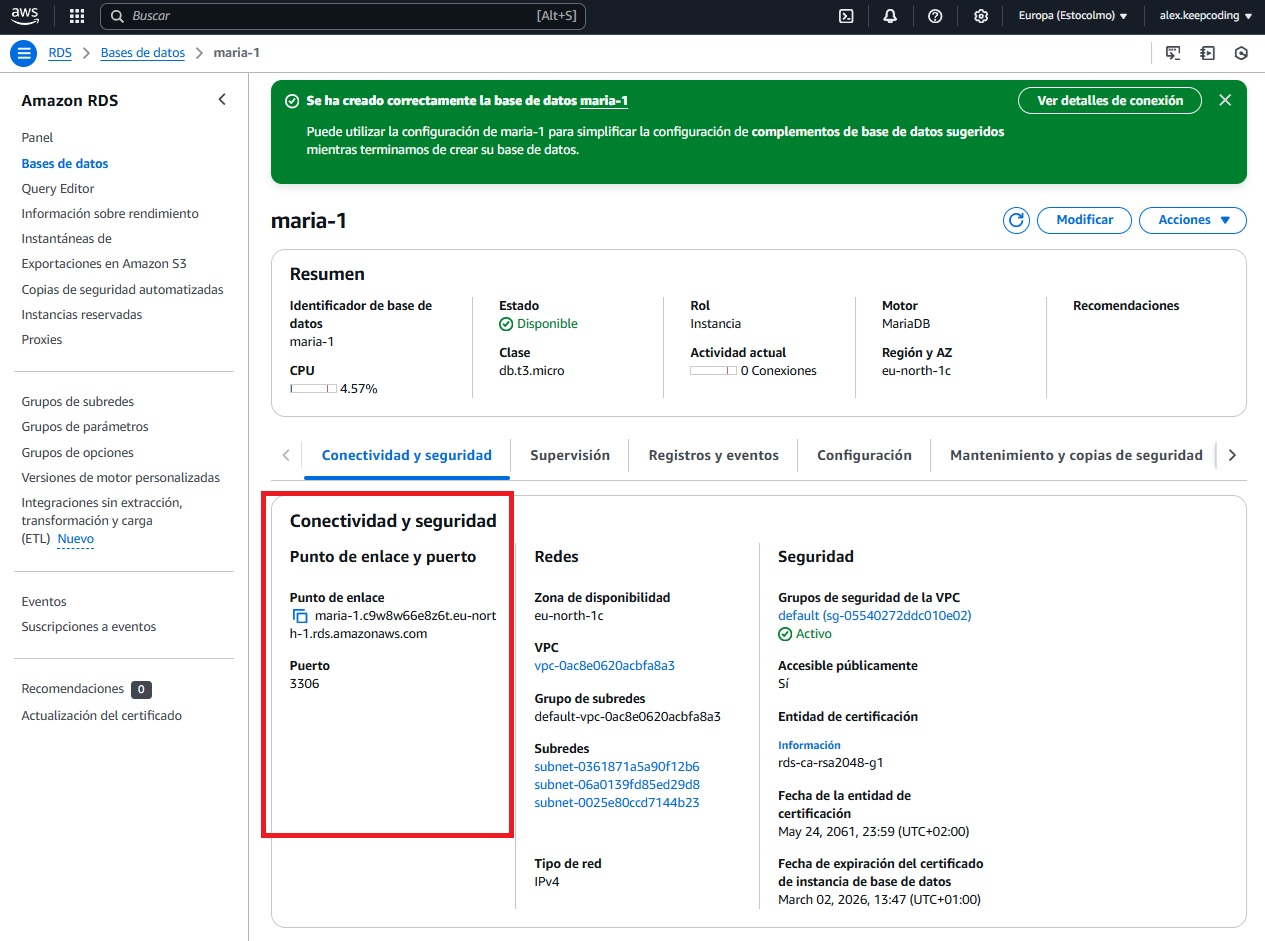

2- Ahora vamos a conectarnos desde el notebook:

In [ ]:
!pip install mysql-connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 48.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mysql-connector: filename=mysql_connector-2.2.9-cp311-cp311-linux_x86_64.whl size=247949 sha256=7ef6b3fff353e57d20eaa811d72c4747793d911451996b90da2011dc2962ca07
  Stored in directory: /root/.cache/pip/wheels/17/cd/ed/2d49e9bac69cf09382e4c7cc20a2511202b48324b87db26019
Successfully built mysql-connector


In [ ]:
import mysql.connector

# Parámetros de conexión
host = "maria-1.c9w8w66e8z6t.eu-north-1.rds.amazonaws.com"  # Aquí el Endpoint de tu base de datos RDS
user = "admin"  # El nombre de usuario
password = "password"  # La contraseña
database = ""  # El nombre de la base de datos, de momento vacio porque no hemos creado ninguna, solo la instancia

# Crear una conexión
connection = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=database
)

# Crear un cursor para interactuar con la base de datos
cursor = connection.cursor()

# Ejecutar una consulta simple
cursor.execute("SELECT VERSION();")
version = cursor.fetchone()
print(f"Conectado a MariaDB versión: {version[0]}")

# Cerrar la conexión
cursor.close()
connection.close()


Conectado a MariaDB versión: 11.4.4-MariaDB


** Enhorabuena! Ya has creado y configurado tu instancia de MariaDB en AWS, y te has conectado desde este notebook**

## Ahora, vamos a crear una base de datos y a agregarle algo de info!

In [ ]:
import mysql.connector


connection = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=database
)

# Crear un cursor para interactuar con la base de datos
cursor = connection.cursor()

# Crear base de datos y cambiar a ella
cursor.execute("CREATE DATABASE IF NOT EXISTS test_db") # Vamos a crear la base de datos llamada test_db
cursor.execute("USE test_db")

# Crear la tabla "users" si no existe
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INT AUTO_INCREMENT PRIMARY KEY,
    name VARCHAR(100),
    email VARCHAR(100)
)
""")

# Insertar datos en la tabla "users"
cursor.execute("INSERT INTO users (name, email) VALUES ('Juan Pérez', 'juan@example.com')")
cursor.execute("INSERT INTO users (name, email) VALUES ('Ana García', 'ana@example.com')")

# Confirmar los cambios en la base de datos
connection.commit()

In [ ]:
# Vamos a consultar la nueva tabla creada y los datos introducidos:

# Consultar los datos insertados
cursor.execute("SELECT * FROM users")
result = cursor.fetchall()

# Mostrar los resultados
for row in result:
    print(row)

# Cerrar la conexión
cursor.close()
connection.close()


(1, 'Juan Pérez', 'juan@example.com')
(2, 'Ana García', 'ana@example.com')


Perfecto! Hemos creado una base de datos, con una tabla, y hemos insertado algunos campos que después hemos consultado.

## ¿Comparamos con PostgreSQL en GCP?

- AWS ofrece una mayor variedad de configuraciones y opciones para personalización y escalabilidad.
- GCP proporciona un servicio más simplificado para bases de datos relacionales, con menos opciones pero más optimizado para análisis de datos y AI.
- En GCP, podrías usar Cloud SQL para gestionar bases de datos MariaDB con una configuración similar.

- MariaDB es una excelente opción si necesitas una base de datos relacional ligera, rápida y con compatibilidad total con MySQL.
- Es ideal para aplicaciones con requisitos sencillos de base de datos y que no requieren características avanzadas de PostgreSQL como la integridad de datos compleja o transacciones muy avanzadas.


# Conclusión:

En este notebook hemos hecho unas cuantas cosas!

- Aprendimos a crear una base de datos MariaDB en Amazon RDS
- Tuvimos que configurar firewall y grupo de seguridad (En GCP era mucho más simple, tan solo había que configurar una regla de Firewall)
- Creamos una base de datos
- Creamos una tabla en nuestra base de datos MariaDB
- Insertamos datos
- Consultamos datos

Ahora, puedes probar a "jugar" con esta base de datos y crear otras, también intentar replicar esta tarea en Google Cloud con Cloud SQL

In [ ]:
#Cargar bases de datos y simular trabajos como los realizados con Google Cloud Platform